<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week6/Day2/Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import math

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

        # Projections linéaires individuelles
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        # x shape: [batch_size, seq_len, d_model]
        B, T, C = x.shape

        # 1. Projections
        Q = self.q_linear(x) # [B, T, C]
        K = self.k_linear(x) # [B, T, C]
        V = self.v_linear(x) # [B, T, C]

        # 2. Calcul des scores d'attention (Scaled Dot-Product)
        # Transposition de K pour la multiplication matricielle : [B, C, T]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(C) # [B, T, T]

        # Application du masque optionnel (ex: pour ignorer le padding)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # 3. Softmax pour obtenir les poids d'attention
        attention_weights = torch.softmax(scores, dim=-1) # [B, T, T]

        # 4. Multiplication par les valeurs
        output = torch.matmul(attention_weights, V) # [B, T, C]

        return output, attention_weights

# --- Validation des formes (Shapes) ---
B, T, C = 2, 5, 64  # Batch=2, Seq_len=5, Hidden_dim=64
dummy_input = torch.randn(B, T, C)
sha = SingleHeadAttention(d_model=C)
output, weights = sha(dummy_input)

print("--- SINGLE HEAD VALIDATION ---")
print(f"Input Shape:  {dummy_input.shape}")
print(f"Output Shape: {output.shape}")   # Doit être [2, 5, 64]
print(f"Weights Shape:{weights.shape}")  # Doit être [2, 5, 5]


--- SINGLE HEAD VALIDATION ---
Input Shape:  torch.Size([2, 5, 64])
Output Shape: torch.Size([2, 5, 64])
Weights Shape:torch.Size([2, 5, 5])


In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model doit être divisible par num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Projections groupées pour Q, K, V en une seule matrice linéaire
        self.qkv_linear = nn.Linear(d_model, d_model * 3)

        # Projection finale de sortie
        self.out_linear = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape

        # 1. Projection linéaire globale et séparation en Q, K, V
        qkv = self.qkv_linear(x) # [B, T, 3 * C]
        Q, K, V = torch.chunk(qkv, 3, dim=-1) # Chacun est [B, T, C]

        # 2. Séparation en multiples têtes (Reshape & Transpose)
        # Objectif final de forme : [batch_size, num_heads, seq_len, d_k]
        Q = Q.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        # 3. Scaled Dot-Product Attention par tête
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k) # [B, num_heads, T, T]

        if mask is not None:
            # Ajustement de la forme du masque pour s'aligner sur les têtes [B, 1, 1, T] ou [B, 1, T, T]
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        # Application des poids sur V
        context = torch.matmul(attention_weights, V) # [B, num_heads, T, d_k]

        # 4. Concaténation des têtes (Permute & Reshape)
        context = context.transpose(1, 2).contiguous().view(B, T, C) # Retour à [B, T, C]

        # 5. Projection finale de sortie
        output = self.out_linear(context)

        return output, attention_weights

# --- Validation des formes (Shapes) ---
mha = MultiHeadAttention(d_model=64, num_heads=8)
mha_output, mha_weights = mha(dummy_input)

print("\n--- MULTI HEAD VALIDATION ---")
print(f"MHA Output Shape:  {mha_output.shape}")   # Doit être [2, 5, 64]
print(f"MHA Weights Shape: {mha_weights.shape}")  # Doit être [2, 8, 5, 5]



--- MULTI HEAD VALIDATION ---
MHA Output Shape:  torch.Size([2, 5, 64])
MHA Weights Shape: torch.Size([2, 8, 5, 5])


In [4]:
class FeedForward(nn.Module):
    """ Couche Feed-Forward standard des Transformers """
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class TransformerEncoderBlock(nn.Module):
    """ Un bloc complet : MHA + FeedForward + LayerNorm + Résiduels """
    def __init__(self, d_model, num_heads, d_ff=2048, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Sous-couche d'attention avec connexion résiduelle Pre-LN
        attn_out, weights = self.mha(self.ln1(x), mask=mask)
        x = x + attn_out

        # Sous-couche Feed-Forward
        x = x + self.ffn(self.ln2(x))
        return x, weights

class CustomTransformerClassifier(nn.Module):
    """ Classifieur complet pour le NLI """
    def __init__(self, vocab_size, d_model, num_heads, num_layers, num_classes=3, max_len=128):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads) for _ in range(num_layers)
        ])

        self.ln_head = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, mask=None):
        B, T = input_ids.shape
        positions = torch.arange(0, T, device=input_ids.device).unsqueeze(0)

        # Somme des embeddings de tokens et de positions
        x = self.token_emb(input_ids) + self.pos_emb(positions)

        # Passage à travers les couches de l'encodeur
        all_weights = []
        for layer in self.layers:
            x, weights = layer(x, mask=mask)
            all_weights.append(weights)

        # Pooling : On prend la représentation du premier token (style token [CLS])
        cls_representation = self.ln_head(x[:, 0, :])
        logits = self.fc_out(cls_representation)

        return logits, all_weights


In [5]:
# Exemple de configuration et d'initialisation
VOCAB_SIZE = 30522  # Taille standard du vocabulaire BERT
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
NUM_CLASSES = 3      # Entailment, Neutral, Contradiction

model = CustomTransformerClassifier(VOCAB_SIZE, D_MODEL, NUM_HEADS, NUM_LAYERS, NUM_CLASSES)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

# --- Boucle d'entraînement simplifiée ---
# for epoch in range(epochs):
#     model.train()
#     for batch in dataloader:
#         input_ids = batch['input_ids']      # [B, T]
#         attention_mask = batch['mask']      # [B, T] -> à transformer en [B, 1, 1, T] pour le calcul des scores
#         labels = batch['labels']
#
#         # Formatage du masque pour l'attention
#         mask = attention_mask.unsqueeze(1).unsqueeze(2)
#
#         optimizer.zero_grad()
#         logits, _ = model(input_ids, mask=mask)
#         loss = criterion(logits, labels)
#         loss.backward()
#         optimizer.step()


Forme de l'entrée : torch.Size([2, 5, 64])
Forme de la sortie : torch.Size([2, 5, 64])
Forme des poids d'attention : torch.Size([2, 8, 5, 5])


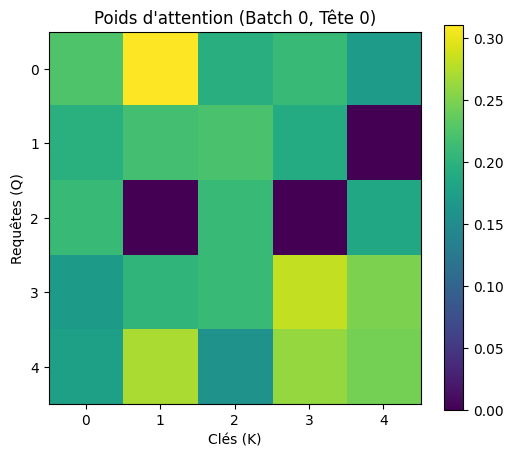

In [8]:
import matplotlib.pyplot as plt

# Configuration de la couche MHA
d_model = 64
num_heads = 8
mha_layer = MultiHeadAttention(d_model=d_model, num_heads=num_heads)

# Passage des données à travers la couche
output, weights = mha_layer(dummy_input)

print(f"Forme de l'entrée : {dummy_input.shape}")
print(f"Forme de la sortie : {output.shape}")
print(f"Forme des poids d'attention : {weights.shape}")

# Visualisation rapide des poids d'attention pour la première tête du premier batch
plt.figure(figsize=(6, 5))
plt.imshow(weights[0, 0].detach().numpy(), cmap='viridis')
plt.colorbar()
plt.title("Poids d'attention (Batch 0, Tête 0)")
plt.xlabel("Clés (K)")
plt.ylabel("Requêtes (Q)")
plt.show()